# DSA Stop-and-Stare Survey: TOD Simulation and Map-Making

This notebook demonstrates a stop-and-stare (steering-and-shift) observation strategy for DSA single-dish observations using the `limTOD` package. Unlike traditional azimuthal scanning (e.g., MeerKLASS), each pointing **tracks a fixed (RA, Dec)** position, so both azimuth and elevation change over time.

The scan design follows a 3x3 hexagonal grid centered on (RA=180deg, Dec=52deg), inspired by the CASS survey design and uGMRT paper. Each pointing is observed for 21 minutes, yielding ~189 minutes of total observation.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
from limTOD import TODSim, GDSM_sky_model, HPW_mapmaking
from dsa_vis import plot_patch, plot_map_compare
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import SkyCoord, AltAz, EarthLocation
from astropy.time import Time, TimeDelta
import astropy.units as u

In [2]:
# DSA site location
DSA_LAT, DSA_LON, DSA_HGT = 39.553969, -114.423973, 1746.51
dsa_location = EarthLocation(lat=DSA_LAT*u.deg, lon=DSA_LON*u.deg, height=DSA_HGT*u.m)


def radec_to_azel(ra_deg, dec_deg, time_list_sec, start_time_utc, location):
    """Convert fixed (RA, Dec) to time-varying (Az, El) arrays."""
    start = Time(start_time_utc)
    times = start + TimeDelta(time_list_sec, format='sec')
    target = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame='icrs')
    altaz = target.transform_to(AltAz(obstime=times, location=location))
    return altaz.az.deg, altaz.alt.deg


# Beam loader with caching
_beam_cache = {}

def dsa_beam_func(*, freq, nside):
    if nside not in _beam_cache:
        beam_128 = hp.read_map('beam_map_zenith.fits')
        if nside != 128:
            _beam_cache[nside] = hp.ud_grade(beam_128, nside)
        else:
            _beam_cache[nside] = beam_128.copy()
    beam = _beam_cache[nside].copy()
    beam /= np.sum(beam)
    return beam


# TOD simulator (forward model) — match the beam's native resolution
sky_Nside = 64
beam_Nside = 128  # nside=128 avoids lmax truncation ripples in rotate_alm

# Map-maker (inverse problem) — pixel scale ~ beam scale.
# FWHM ≈ 4.5°  vs  pixel size: nside=16 → 3.66°, nside=32 → 1.83°.
# nside=16 makes each pixel essentially one beam, so the inverse problem
# becomes nearly diagonal and very well-conditioned.
sky_Nside_map = 16
beam_Nside_map = 32

tod_sim = TODSim(
    ant_latitude_deg=DSA_LAT,
    ant_longitude_deg=DSA_LON,
    ant_height_m=DSA_HGT,
    beam_func=dsa_beam_func,
    sky_func=GDSM_sky_model,
    beam_nside=beam_Nside,
    sky_nside=sky_Nside,
)

truncate_frac_thres = 1e-3  # larger truncation to avoid alm ringing at beam edges
freq_list = [1000]  # MHz

In [3]:
# Define 3x3 hex pointing grid centered on (RA=180, Dec=52)
center_ra, center_dec = 180.0, 52.0
d_dec = 3.5
d_ra = 3.5 / np.cos(np.radians(center_dec))

pointings = []
for i_row, dec_offset in enumerate([-d_dec, 0, d_dec]):
    ra_shift = d_ra / 2 if i_row % 2 == 1 else 0
    for ra_offset in [-d_ra, 0, d_ra]:
        pointings.append((center_ra + ra_offset + ra_shift, center_dec + dec_offset))
pointings = np.array(pointings)

print(f"9-pointing hex grid centered on (RA={center_ra}, Dec={center_dec}):")
for i, (ra, dec) in enumerate(pointings):
    print(f"  PC {i}: ({ra:.2f}, {dec:.2f})")

9-pointing hex grid centered on (RA=180.0, Dec=52.0):
  PC 0: (174.32, 48.50)
  PC 1: (180.00, 48.50)
  PC 2: (185.68, 48.50)
  PC 3: (177.16, 52.00)
  PC 4: (182.84, 52.00)
  PC 5: (188.53, 52.00)
  PC 6: (174.32, 55.50)
  PC 7: (180.00, 55.50)
  PC 8: (185.68, 55.50)


In [4]:
# Generate TODs for all pointings (or load from cache)
try:
    data = np.load("simulated_TODs_steer_stare.npz", allow_pickle=True)
    freq_list = data["freq_list"].tolist()
    TOD_group = data["TOD_group"]
    LST_deg_list_group = data["LST_deg_list_group"]
    azimuth_deg_list_group = data["azimuth_deg_list_group"]
    elevation_deg_list_group = data["elevation_deg_list_group"]
    print("Loaded existing simulated TODs")
except (FileNotFoundError, KeyError):
    base_start = "2024-04-15 04:00:00"
    t_per_pointing = 21 * 60  # 21 minutes in seconds
    dt = 2.0

    TOD_group = []
    LST_deg_list_group = []
    azimuth_deg_list_group = []
    elevation_deg_list_group = []

    print("Generating simulated TODs...")
    for i, (ra_i, dec_i) in enumerate(pointings):
        start_i = (Time(base_start) + TimeDelta(i * t_per_pointing, format='sec')).iso
        time_list_i = np.arange(0, t_per_pointing, dt)

        az_i, el_i = radec_to_azel(ra_i, dec_i, time_list_i, start_i, dsa_location)

        print(f"  PC {i}: (RA={ra_i:.1f}, Dec={dec_i:.1f}), el=[{el_i.min():.1f},{el_i.max():.1f}]")

        tod_array, _, _, LST_deg_list = tod_sim.generate_TOD(
            freq_list=freq_list,
            time_list=time_list_i,
            azimuth_deg_list=az_i,
            elevation_deg=el_i,  # LIST, not scalar!
            start_time_utc=start_i,
            return_LSTs=True,
            normalize_beam=False,
            truncate_frac_thres=truncate_frac_thres,
        )
        TOD_group.append(tod_array[0])
        LST_deg_list_group.append(LST_deg_list)
        azimuth_deg_list_group.append(az_i)
        elevation_deg_list_group.append(el_i)

    np.savez("simulated_TODs_steer_stare.npz",
        TOD_group=TOD_group,
        LST_deg_list_group=LST_deg_list_group,
        azimuth_deg_list_group=azimuth_deg_list_group,
        elevation_deg_list_group=elevation_deg_list_group,
        freq_list=freq_list,
    )
    print("Done! Saved to simulated_TODs_steer_stare.npz")

Generating simulated TODs...


  PC 0: (RA=174.3, Dec=48.5), el=[69.9,73.2]
No white noise variance is specified!! Using default value of 2.5e-6 (Dimensionless fractional noise)
Generating gain noise with parameters: f0=1.335e-05, fc=0.001099, alpha=2.
Note that these 1/f noise are uncorrelated in frequencies.


  0%|          | 0/630 [00:00<?, ?it/s]

  0%|          | 1/630 [00:00<02:39,  3.93it/s]

  0%|          | 2/630 [00:00<02:31,  4.13it/s]

...

100%|█████████▉| 628/630 [04:35<00:00,  2.28it/s]

100%|█████████▉| 629/630 [04:35<00:00,  2.28it/s]

100%|██████████| 630/630 [04:36<00:00,  2.28it/s]

100%|██████████| 630/630 [04:36<00:00,  2.28it/s]

Done! Saved to simulated_TODs_steer_stare.npz


In [5]:
# Build HPW mapmaker (expensive — caches the fitted operator via pickle).
# Depends only on beam + scan geometry + nside_target, not on map-making
# parameters (cutoff_freq, prior), so we can iterate on those without rebuilding.
import pickle

# Cache key embeds the nside choice so old (nside=64) caches aren't accidentally reused.
OPS_CACHE = f"mapmaker_ops_steer_stare_ns{sky_Nside_map}.pkl"

try:
    with open(OPS_CACHE, "rb") as f:
        HPW_mapmaker = pickle.load(f)
    print(f"Loaded cached HPW_mapmaker operator from {OPS_CACHE}")
except (FileNotFoundError, EOFError):
    # Build beam at mapmaker resolution (nside=64), used to derive alm internally.
    beam_map = dsa_beam_func(freq=freq_list[0], nside=beam_Nside_map)
    lat_deg = tod_sim.ant_latitude_deg

    HPW_mapmaker = HPW_mapmaking(
        beam_map=beam_map,
        LST_deg_list_group=LST_deg_list_group,
        lat_deg=lat_deg,
        azimuth_deg_list_group=azimuth_deg_list_group,
        elevation_deg_list_group=elevation_deg_list_group,
        threshold=0.05,
        nside_target=sky_Nside_map,
        beam_truncate_frac_thres=truncate_frac_thres,
    )
    with open(OPS_CACHE, "wb") as f:
        pickle.dump(HPW_mapmaker, f)
    print(f"Built HPW_mapmaker and cached to {OPS_CACHE}")

pixel_indices = HPW_mapmaker.pixel_indices
print(f"Pixel selection: {len(pixel_indices)} pixels at nside={sky_Nside_map}")

Loaded cached HPW_mapmaker operator from mapmaker_ops_steer_stare_ns16.pkl
Pixel selection: 22 pixels at nside=16


In [6]:
# Map-making: no high-pass filter + mild GDSM prior
# - cutoff_freq = 1e-5 Hz with filter_order=1  => butter bandpass ~= identity
#   (period ~28 h; our TOD spans ~3 h, so nothing is filtered in practice)
# - Tsky_prior_mean = GDSM at the recovered pixels (anchors the absolute level)
# - Tsky_prior_inv_cov_diag = 1/sigma_prior^2  with sigma_prior=50 K  (mild)
sky_truth = GDSM_sky_model(freq=freq_list[0], nside=sky_Nside_map)[pixel_indices]

prior_sigma_K = 50.0
prior_inv_cov = np.ones_like(sky_truth) / prior_sigma_K**2

cutoff_freq_group = [1e-5] * len(TOD_group)

sky_map_est, sky_map_uncertainty = HPW_mapmaker(
    TOD_group=np.array(TOD_group),
    dtime=2.0,
    cutoff_freq_group=np.array(cutoff_freq_group),
    gain_group=None,
    known_injection_group=None,
    Tsky_prior_mean=sky_truth,
    Tsky_prior_inv_cov_diag=prior_inv_cov,
    regularization=1e-12,
    return_full_cov=False,
    filter_order=1,
)

print(f"sky_map_est:  min={sky_map_est.min():.3f} K, max={sky_map_est.max():.3f} K, "
      f"mean={sky_map_est.mean():.3f} K")
print(f"sky_truth:    min={sky_truth.min():.3f} K, max={sky_truth.max():.3f} K, "
      f"mean={sky_truth.mean():.3f} K")
print(f"Residual rms: {np.std(sky_map_est - sky_truth):.4f} K")

sky_map_est:  min=-18.625 K, max=16.352 K, mean=-2.972 K
sky_truth:    min=4.609 K, max=4.778 K, mean=4.664 K
Residual rms: 8.6810 K


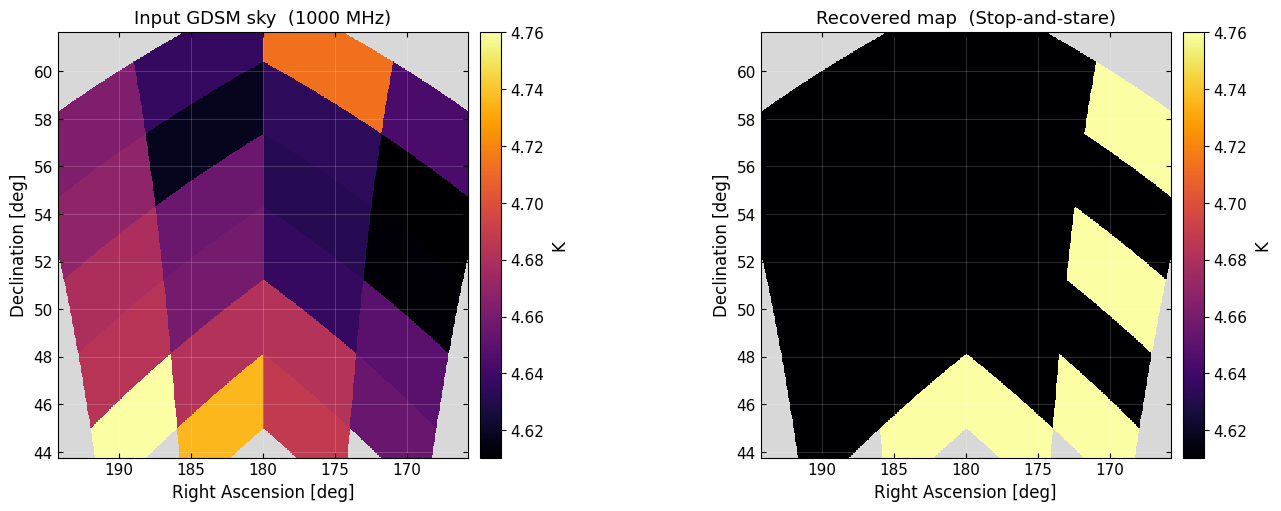

In [7]:
# Side-by-side comparison: input GDSM vs. recovered map
# (sky_truth computed at sky_Nside_map in the previous cell)

fig = plot_map_compare(
    sky_est=sky_map_est,
    sky_truth=sky_truth,
    nside=sky_Nside_map,
    pixel_indices=pixel_indices,
    freq_mhz=freq_list[0],
    strategy_name="Stop-and-stare",
    savepath="figures/map_steer_and_stare.png",
)
plt.show()